In [11]:
import pandas as pd
import torch
import triton

from src.backend.flash_attention import (
    torch_causal_attention,
    flash_causal_attention,
)

def test_forward(
    batch: int = 2,
    heads: int = 4,
    seq_len: int = 128,
    head_dim: int = 64,
    dtype: torch.dtype = torch.float16,
):
    torch.manual_seed(0)

    q = torch.randn(batch, heads, seq_len, head_dim, device="cuda", dtype=dtype)
    k = torch.randn_like(q)
    v = torch.randn_like(q)

    expected = torch_causal_attention(q, k, v)
    actual = flash_causal_attention(q, k, v, block_m=64, block_n=64)

    torch.testing.assert_close(actual, expected, rtol=3e-2, atol=3e-2)
    print("forward ok")
    print("max abs diff:", (actual - expected).abs().max().item())


test_forward()

forward ok
max abs diff: 0.000244140625


In [13]:
def test_backward(
    batch: int = 2,
    heads: int = 4,
    seq_len: int = 128,
    head_dim: int = 64,
    dtype: torch.dtype = torch.float16,
):
    torch.manual_seed(0)

    q_ref = torch.randn(batch, heads, seq_len, head_dim, device="cuda", dtype=dtype, requires_grad=True)
    k_ref = torch.randn_like(q_ref, requires_grad=True)
    v_ref = torch.randn_like(q_ref, requires_grad=True)

    q_tri = q_ref.detach().clone().requires_grad_(True)
    k_tri = k_ref.detach().clone().requires_grad_(True)
    v_tri = v_ref.detach().clone().requires_grad_(True)

    grad = torch.randn_like(q_ref)

    out_ref = torch_causal_attention(q_ref, k_ref, v_ref)
    loss_ref = (out_ref * grad).sum()
    loss_ref.backward()

    out_tri = flash_causal_attention(q_tri, k_tri, v_tri, block_m=64, block_n=64)
    loss_tri = (out_tri * grad).sum()
    loss_tri.backward()

    torch.testing.assert_close(out_tri, out_ref, rtol=3e-2, atol=3e-2)

    torch.testing.assert_close(q_tri.grad, q_ref.grad, rtol=4e-2, atol=4e-2)
    torch.testing.assert_close(k_tri.grad, k_ref.grad, rtol=4e-2, atol=4e-2)
    torch.testing.assert_close(v_tri.grad, v_ref.grad, rtol=4e-2, atol=4e-2)

    print("backward ok")
    print("dq max abs diff:", (q_tri.grad - q_ref.grad).abs().max().item())
    print("dk max abs diff:", (k_tri.grad - k_ref.grad).abs().max().item())
    print("dv max abs diff:", (v_tri.grad - v_ref.grad).abs().max().item())


test_backward()

backward ok
dq max abs diff: 0.0009765625
dk max abs diff: 0.001953125
dv max abs diff: 0.00390625


In [14]:
def benchmark_time(
    seq_lengths=(128, 256, 512, 1024, 2048),
    batch: int = 1,
    heads: int = 8,
    head_dim: int = 64,
    dtype: torch.dtype = torch.float16,
    block_m: int = 64,
    block_n: int = 64,
    warmup: int = 25,
    rep: int = 100,
):
    rows = []

    for seq_len in seq_lengths:
        torch.manual_seed(0)

        q = torch.randn(batch, heads, seq_len, head_dim, device="cuda", dtype=dtype)
        k = torch.randn_like(q)
        v = torch.randn_like(q)

        torch.cuda.synchronize()
        torch_ms = triton.testing.do_bench(
            lambda: torch_causal_attention(q, k, v),
            warmup=warmup,
            rep=rep,
        )

        torch.cuda.synchronize()
        triton_ms = triton.testing.do_bench(
            lambda: flash_causal_attention(q, k, v, block_m=block_m, block_n=block_n),
            warmup=warmup,
            rep=rep,
        )

        row = {
            "seq_len": seq_len,
            "batch": batch,
            "heads": heads,
            "head_dim": head_dim,
            "dtype": str(dtype).replace("torch.", ""),
            "torch_ms": torch_ms,
            "triton_ms": triton_ms,
            "speedup": torch_ms / triton_ms,
        }

        rows.append(row)
        print(row)

    return pd.DataFrame(rows)


df_time = benchmark_time()
print(df_time)

{'seq_len': 128, 'batch': 1, 'heads': 8, 'head_dim': 64, 'dtype': 'float16', 'torch_ms': 0.14901094785646388, 'triton_ms': 0.30559105732861686, 'speedup': 0.4876155380954921}
{'seq_len': 256, 'batch': 1, 'heads': 8, 'head_dim': 64, 'dtype': 'float16', 'torch_ms': 0.17798000015318394, 'triton_ms': 0.6960533327526517, 'speedup': 0.25569879746043916}
{'seq_len': 512, 'batch': 1, 'heads': 8, 'head_dim': 64, 'dtype': 'float16', 'torch_ms': 0.5074442694584529, 'triton_ms': 2.5223691904986345, 'speedup': 0.20117763544286663}
{'seq_len': 1024, 'batch': 1, 'heads': 8, 'head_dim': 64, 'dtype': 'float16', 'torch_ms': 1.8284950571901657, 'triton_ms': 10.081272006034851, 'speedup': 0.18137543120506935}
{'seq_len': 2048, 'batch': 1, 'heads': 8, 'head_dim': 64, 'dtype': 'float16', 'torch_ms': 7.1914719343185425, 'triton_ms': 39.42550277709961, 'speedup': 0.18240660049351926}
   seq_len  batch  heads  head_dim    dtype  torch_ms  triton_ms   speedup
0      128      1      8        64  float16  0.14901

In [15]:
def measure_peak_memory(fn):
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    out = fn()

    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated()

    del out
    torch.cuda.empty_cache()

    return peak / 1024 ** 2


def benchmark_memory_forward(
    seq_lengths=(128, 256, 512, 1024, 2048),
    batch: int = 1,
    heads: int = 8,
    head_dim: int = 64,
    dtype: torch.dtype = torch.float16,
    block_m: int = 64,
    block_n: int = 64,
):
    rows = []

    for seq_len in seq_lengths:
        torch.manual_seed(0)

        q = torch.randn(batch, heads, seq_len, head_dim, device="cuda", dtype=dtype)
        k = torch.randn_like(q)
        v = torch.randn_like(q)

        torch_mem = measure_peak_memory(
            lambda: torch_causal_attention(q, k, v)
        )

        triton_mem = measure_peak_memory(
            lambda: flash_causal_attention(q, k, v, block_m=block_m, block_n=block_n)
        )

        row = {
            "seq_len": seq_len,
            "batch": batch,
            "heads": heads,
            "head_dim": head_dim,
            "dtype": str(dtype).replace("torch.", ""),
            "torch_peak_mem_mb": torch_mem,
            "triton_peak_mem_mb": triton_mem,
            "memory_ratio": torch_mem / triton_mem,
        }

        rows.append(row)
        print(row)

    return pd.DataFrame(rows)


df_memory = benchmark_memory_forward()
print(df_memory)

{'seq_len': 128, 'batch': 1, 'heads': 8, 'head_dim': 64, 'dtype': 'float16', 'torch_peak_mem_mb': 23.65625, 'triton_peak_mem_mb': 22.26953125, 'memory_ratio': 1.0622697772320646}
{'seq_len': 256, 'batch': 1, 'heads': 8, 'head_dim': 64, 'dtype': 'float16', 'torch_peak_mem_mb': 27.578125, 'triton_peak_mem_mb': 22.7734375, 'memory_ratio': 1.2109777015437393}
{'seq_len': 512, 'batch': 1, 'heads': 8, 'head_dim': 64, 'dtype': 'float16', 'torch_peak_mem_mb': 41.515625, 'triton_peak_mem_mb': 23.78125, 'memory_ratio': 1.7457293035479633}
{'seq_len': 1024, 'batch': 1, 'heads': 8, 'head_dim': 64, 'dtype': 'float16', 'torch_peak_mem_mb': 93.765625, 'triton_peak_mem_mb': 25.796875, 'memory_ratio': 3.6347668079951543}
{'seq_len': 2048, 'batch': 1, 'heads': 8, 'head_dim': 64, 'dtype': 'float16', 'torch_peak_mem_mb': 295.765625, 'triton_peak_mem_mb': 29.828125, 'memory_ratio': 9.91566265060241}
   seq_len  batch  heads  head_dim    dtype  torch_peak_mem_mb  \
0      128      1      8        64  float1

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Объединим результаты по времени и памяти
df = df_time.merge(
    df_memory[["seq_len", "torch_peak_mem_mb", "triton_peak_mem_mb", "memory_ratio"]],
    on="seq_len",
)

# Дополнительно посчитаем, во сколько раз Triton медленнее Torch
df["triton_slower_x"] = df["triton_ms"] / df["torch_ms"]

df

,seq_len,batch,heads,head_dim,dtype,torch_ms,triton_ms,speedup,torch_peak_mem_mb,triton_peak_mem_mb,memory_ratio,triton_slower_x
0,128,1,8,64,float16,0.149011,0.305591,0.487616,23.656250,22.269531,1.062270,2.050796
1,256,1,8,64,float16,0.177980,0.696053,0.255699,27.578125,22.773438,1.210978,3.910851
2,512,1,8,64,float16,0.507444,2.522369,0.201178,41.515625,23.781250,1.745729,4.970731
3,1024,1,8,64,float16,1.828495,10.081272,0.181375,93.765625,25.796875,3.634767,5.513426
4,2048,1,8,64,float16,7.191472,39.425503,0.182407,295.765625,29.828125,9.915663,5.482258


### Графики сравнения времени и памяти

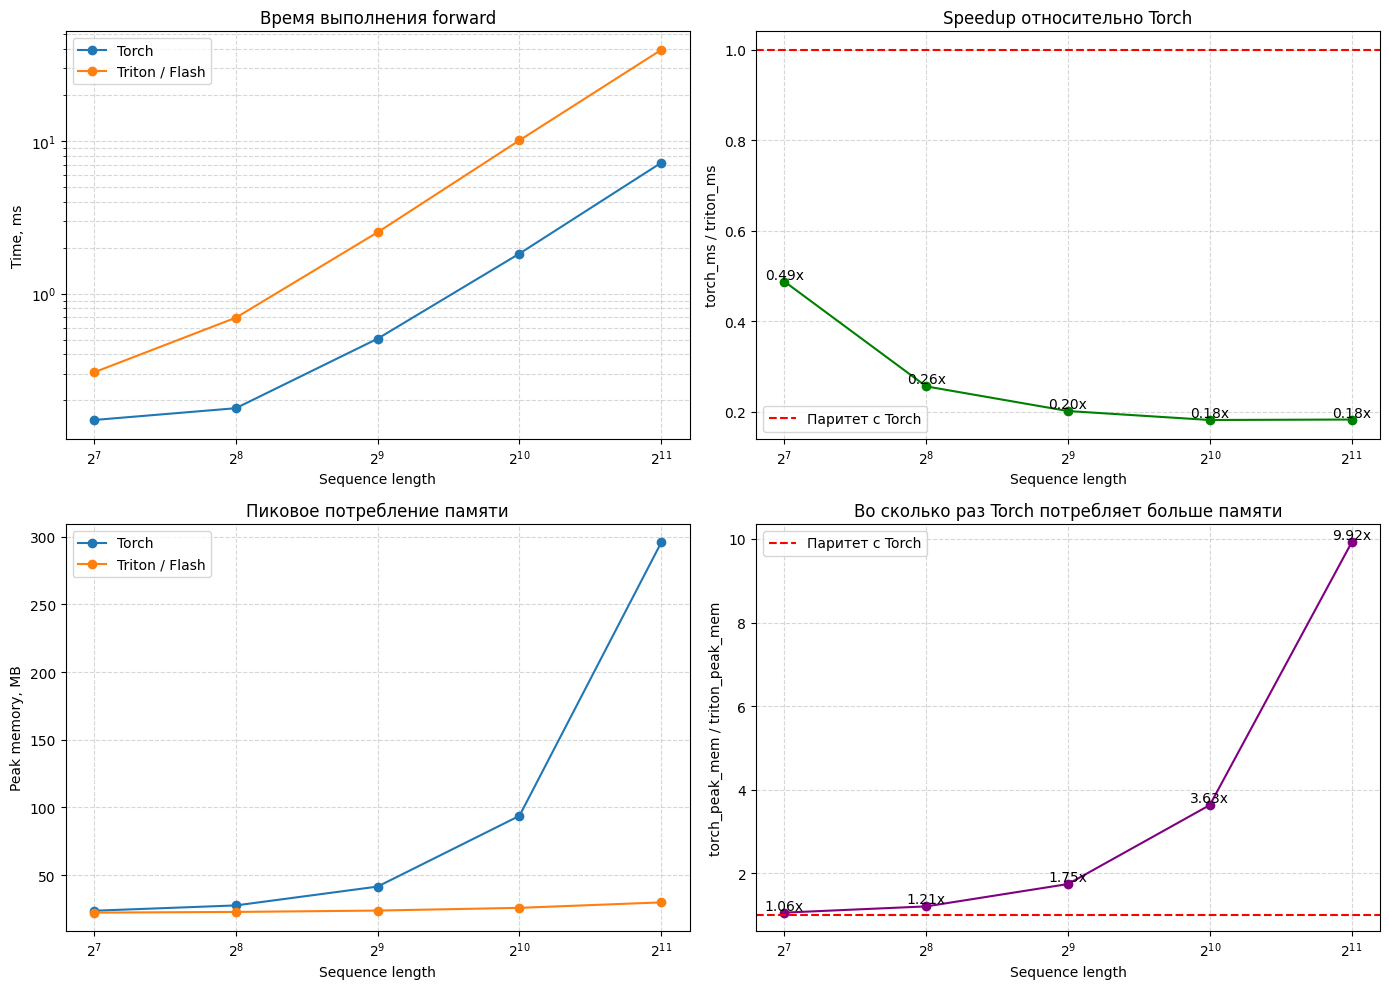

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Время выполнения
ax = axes[0, 0]
ax.plot(df["seq_len"], df["torch_ms"], marker="o", label="Torch")
ax.plot(df["seq_len"], df["triton_ms"], marker="o", label="Triton / Flash")
ax.set_title("Время выполнения forward")
ax.set_xlabel("Sequence length")
ax.set_ylabel("Time, ms")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.legend()

# 2. Speedup = torch_ms / triton_ms
ax = axes[0, 1]
ax.plot(df["seq_len"], df["speedup"], marker="o", color="green")
ax.axhline(1.0, color="red", linestyle="--", label="Паритет с Torch")
ax.set_title("Speedup относительно Torch")
ax.set_xlabel("Sequence length")
ax.set_ylabel("torch_ms / triton_ms")
ax.set_xscale("log", base=2)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.legend()

for x, y in zip(df["seq_len"], df["speedup"]):
    ax.text(x, y, f"{y:.2f}x", ha="center", va="bottom")

# 3. Пиковое потребление памяти
ax = axes[1, 0]
ax.plot(df["seq_len"], df["torch_peak_mem_mb"], marker="o", label="Torch")
ax.plot(df["seq_len"], df["triton_peak_mem_mb"], marker="o", label="Triton / Flash")
ax.set_title("Пиковое потребление памяти")
ax.set_xlabel("Sequence length")
ax.set_ylabel("Peak memory, MB")
ax.set_xscale("log", base=2)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.legend()

# 4. Экономия памяти
ax = axes[1, 1]
ax.plot(df["seq_len"], df["memory_ratio"], marker="o", color="purple")
ax.axhline(1.0, color="red", linestyle="--", label="Паритет с Torch")
ax.set_title("Во сколько раз Torch потребляет больше памяти")
ax.set_xlabel("Sequence length")
ax.set_ylabel("torch_peak_mem / triton_peak_mem")
ax.set_xscale("log", base=2)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.legend()

for x, y in zip(df["seq_len"], df["memory_ratio"]):
    ax.text(x, y, f"{y:.2f}x", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Во сколько раз реализация медленнее Torch

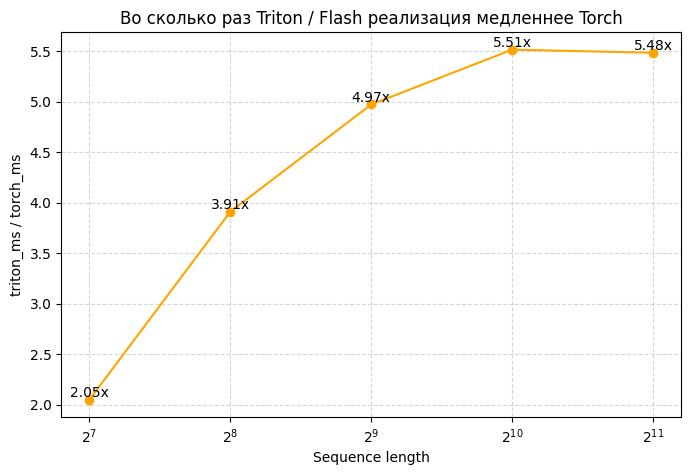

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    df["seq_len"],
    df["triton_slower_x"],
    marker="o",
    color="orange",
)

plt.title("Во сколько раз Triton / Flash реализация медленнее Torch")
plt.xlabel("Sequence length")
plt.ylabel("triton_ms / torch_ms")
plt.xscale("log", base=2)
plt.grid(True, which="both", linestyle="--", alpha=0.5)

for x, y in zip(df["seq_len"], df["triton_slower_x"]):
    plt.text(x, y, f"{y:.2f}x", ha="center", va="bottom")

plt.show()